##  1. Выделение ROI (Region of Interest)

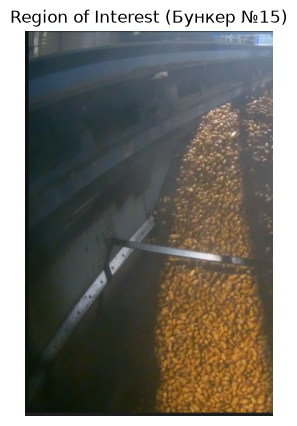

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def load_and_crop_roi(image_path: str | Path, crop_ratio: float = 0.45) -> np.ndarray:
    """
    Загружает изображение и обрезает его, оставляя только левый бункер (№15).
    :param crop_ratio: Доля ширины кадра, которую оставляем (45% отсекает балку).
    """
    # Читаем картинку и переводим в RGB для Matplotlib
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Не найдено изображение: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h, w = img_rgb.shape[:2]
    roi_width = int(w * crop_ratio)
    
    return img_rgb[:, :roi_width]

# Демонстрация
sample_img = "references/bunker15_50.jpg" # Подставь свой путь
roi_img = load_and_crop_roi("../data/raw/50.png")

plt.figure(figsize=(10, 5))
plt.title("Region of Interest (Бункер №15)")
plt.imshow(roi_img)
plt.axis('off')
plt.show()

## 2. Pixel-based baseline (Алгоритм без ML)

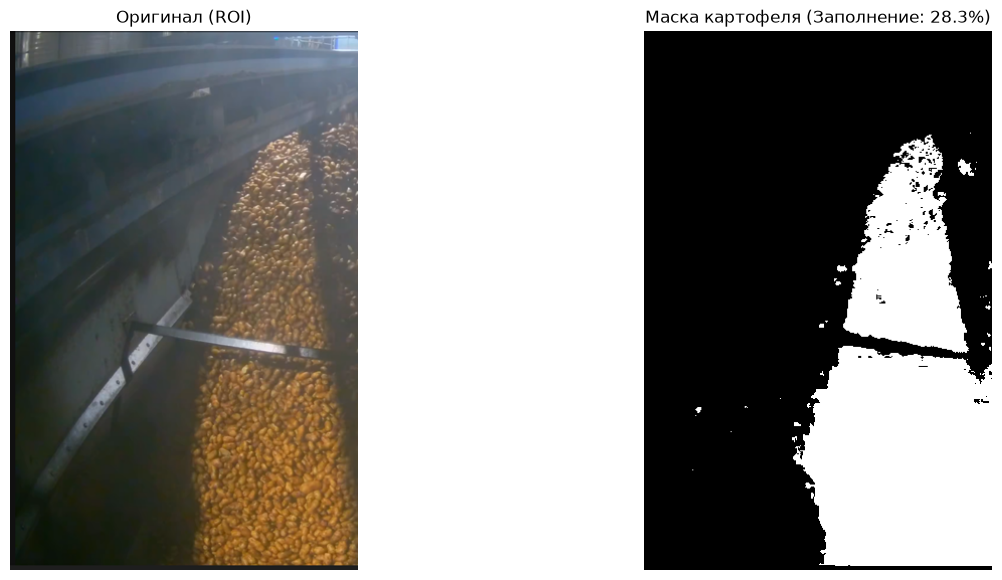

In [7]:
def estimate_fill_baseline_hsv(roi_img: np.ndarray) -> float:
    """
    Оценивает процент заполнения бункера на основе цветовой маски (HSV).
    Это наш Baseline (нулевая линия) для сравнения с нейросетью.
    """
    # Переводим в HSV (Hue, Saturation, Value) — лучше работает при разном освещении
    hsv = cv2.cvtColor(roi_img, cv2.COLOR_RGB2HSV)
    
    # Задаем диапазон цвета картофеля (подбирается эмпирически)
    # Желто-коричневые оттенки
    lower_potato = np.array([10, 50, 50])
    upper_potato = np.array([40, 255, 255])
    
    # Создаем бинарную маску: 255 там где картошка, 0 где фон
    mask = cv2.inRange(hsv, lower_potato, upper_potato)
    
    # Считаем процент
    potato_pixels = cv2.countNonZero(mask)
    total_pixels = mask.shape[0] * mask.shape[1]
    
    fill_percentage = (potato_pixels / total_pixels) * 100
    
    return fill_percentage, mask

fill_pct, mask = estimate_fill_baseline_hsv(roi_img)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
ax1.imshow(roi_img)
ax1.set_title("Оригинал (ROI)")
ax1.axis('off')

ax2.imshow(mask, cmap='gray')
ax2.set_title(f"Маска картофеля (Заполнение: {fill_pct:.1f}%)")
ax2.axis('off')
plt.show()

## 3. Генерация синтетики (Albumentations)

/tmp/ipykernel_12599/2770588830.py:6: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(20.0, 60.0), p=0.5), # Пыль на объективе
/tmp/ipykernel_12599/2770588830.py:8: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=50, quality_upper=80, p=0.7) # Артефакты RTSP


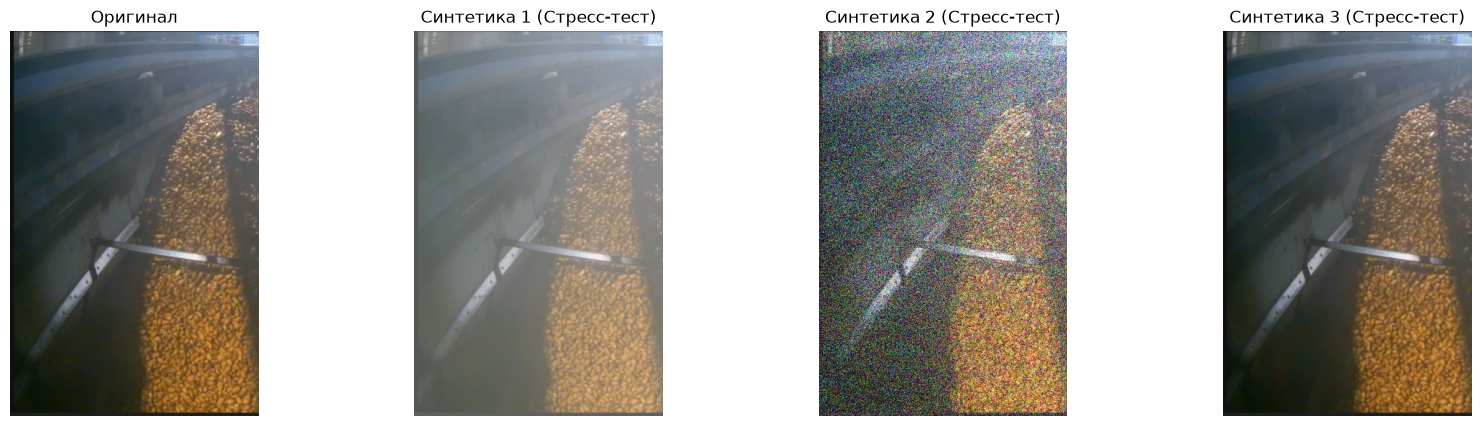

In [8]:
import albumentations as A

# Пайплайн аугментаций, имитирующий суровые заводские условия
factory_transform = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.8), # Блики и тени
    A.GaussNoise(var_limit=(20.0, 60.0), p=0.5), # Пыль на объективе
    A.MotionBlur(blur_limit=7, p=0.3), # Вибрация конвейера
    A.ImageCompression(quality_lower=50, quality_upper=80, p=0.7) # Артефакты RTSP
])

# Генерируем 3 варианта для наглядности
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(roi_img)
axes[0].set_title("Оригинал")
axes[0].axis('off')

for i in range(1, 4):
    augmented = factory_transform(image=roi_img)['image']
    axes[i].imshow(augmented)
    axes[i].set_title(f"Синтетика {i} (Стресс-тест)")
    axes[i].axis('off')

plt.show()